# Predikcija zadovoljstva putnika avio-kompanije primenom neuronskih mreža i algoritama mašinskog učenja

Koristiće se:
- Logistička regresija
- Random Forest
- Višeslojna neuronska mreža (MLP)

# Biblioteke

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier

# Učitavanje podataka

In [3]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
print(f"Train: Broj redova: {train_df.shape[0]}")
print(f"Train: Broj kolona: {train_df.shape[1]}")
print(f"Test: Broj redova: {test_df.shape[0]}")
print(f"Test: Broj kolona: {test_df.shape[1]}")

Train: Broj redova: 103904
Train: Broj kolona: 25
Test: Broj redova: 25976
Test: Broj kolona: 25


Kako su train i test datoteke odvojene, za lakšu analizu spajamo sve u jedan dataframe

In [4]:
df = pd.concat([train_df, test_df], ignore_index=True)
print(f"Broj redova: {df.shape[0]}")
print(f"Broj kolona: {df.shape[1]}")

Broj redova: 129880
Broj kolona: 25


In [5]:
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [6]:
print(f"Kolone: {df.columns.tolist()}")

Kolone: ['Unnamed: 0', 'id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


Prva kolona samo označava broj reda u okviru .csv datoteke

Kako nam ona nije potrebno za analizu i predikciju, uklonićemo je

In [7]:
print(df.dtypes)

Unnamed: 0                             int64
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure 

In [8]:
df.describe()

,Unnamed: 0,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,44158.700000,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,31207.377062,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,0.000000,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16234.750000,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,38963.500000,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,71433.250000,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,103903.000000,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


Kolone koje sadrže nivo satisfakcije treba da imaju raspon od 1 do 5 kao na anketi.

Uočeno je da su minimalne vrednosti u tim kolonama 0, što predstavlja neprimenjenu ocenu (putnik nije koristio tu uslugu, nije dao ocenu za tu uslugu...).

In [9]:
cols = ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
((df[cols] == 0).mean() * 100).sort_values(ascending=False)

Departure/Arrival time convenient    5.143979
Ease of Online booking               4.374808
Inflight wifi service                3.015091
Online boarding                      2.371420
Leg room service                     0.460425
Food and drink                       0.101632
Inflight entertainment               0.013859
Cleanliness                          0.010779
Inflight service                     0.003850
On-board service                     0.003850
Gate location                        0.000770
Seat comfort                         0.000770
Checkin service                      0.000770
Baggage handling                     0.000000
dtype: float64

Kako ne bi ocenu 0 računali kao "lošu" ocenu usluge, te vrednosti ćemo ispuniti medijanom u okviru pripreme podataka kako bi se očuvala distribucija podataka.

In [10]:
missing_values = df.isnull().sum()
print("Missing values analysis: ")
print(missing_values[missing_values > 0])

Missing values analysis: 
Arrival Delay in Minutes    393
dtype: int64


In [11]:
print(f"Broj duplikata: {df.duplicated().sum()}")

Broj duplikata: 0


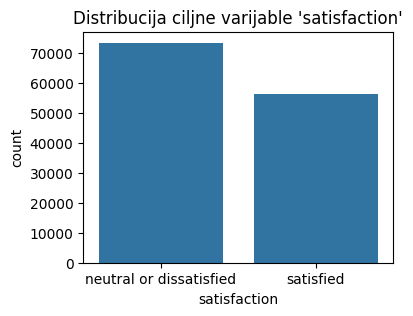

In [12]:
plt.figure(figsize=(4, 3))
sb.countplot(x='satisfaction', data=df)
plt.title("Distribucija ciljne varijable 'satisfaction'")
plt.show()

In [13]:
print(df['satisfaction'].unique())
print(f"Tacan broj zadovoljnih putnika: {df.loc[df['satisfaction'] == 'satisfied'].shape[0]}")
print(f"Tacan broj nezadovoljnih putnika: {df.loc[df['satisfaction'] == 'neutral or dissatisfied'].shape[0]}")

<StringArray>
['neutral or dissatisfied', 'satisfied']
Length: 2, dtype: str
Tacan broj zadovoljnih putnika: 56428
Tacan broj nezadovoljnih putnika: 73452


Dataset je blago neuravnotežen, ali ne zahteva oversampling jer razlika nije ekstremna.

In [14]:
numerical_cols = df.select_dtypes(include=np.number).columns.to_list()
print(f"Numeričke kolone: {numerical_cols}")

Numeričke kolone: ['Unnamed: 0', 'id', 'Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']


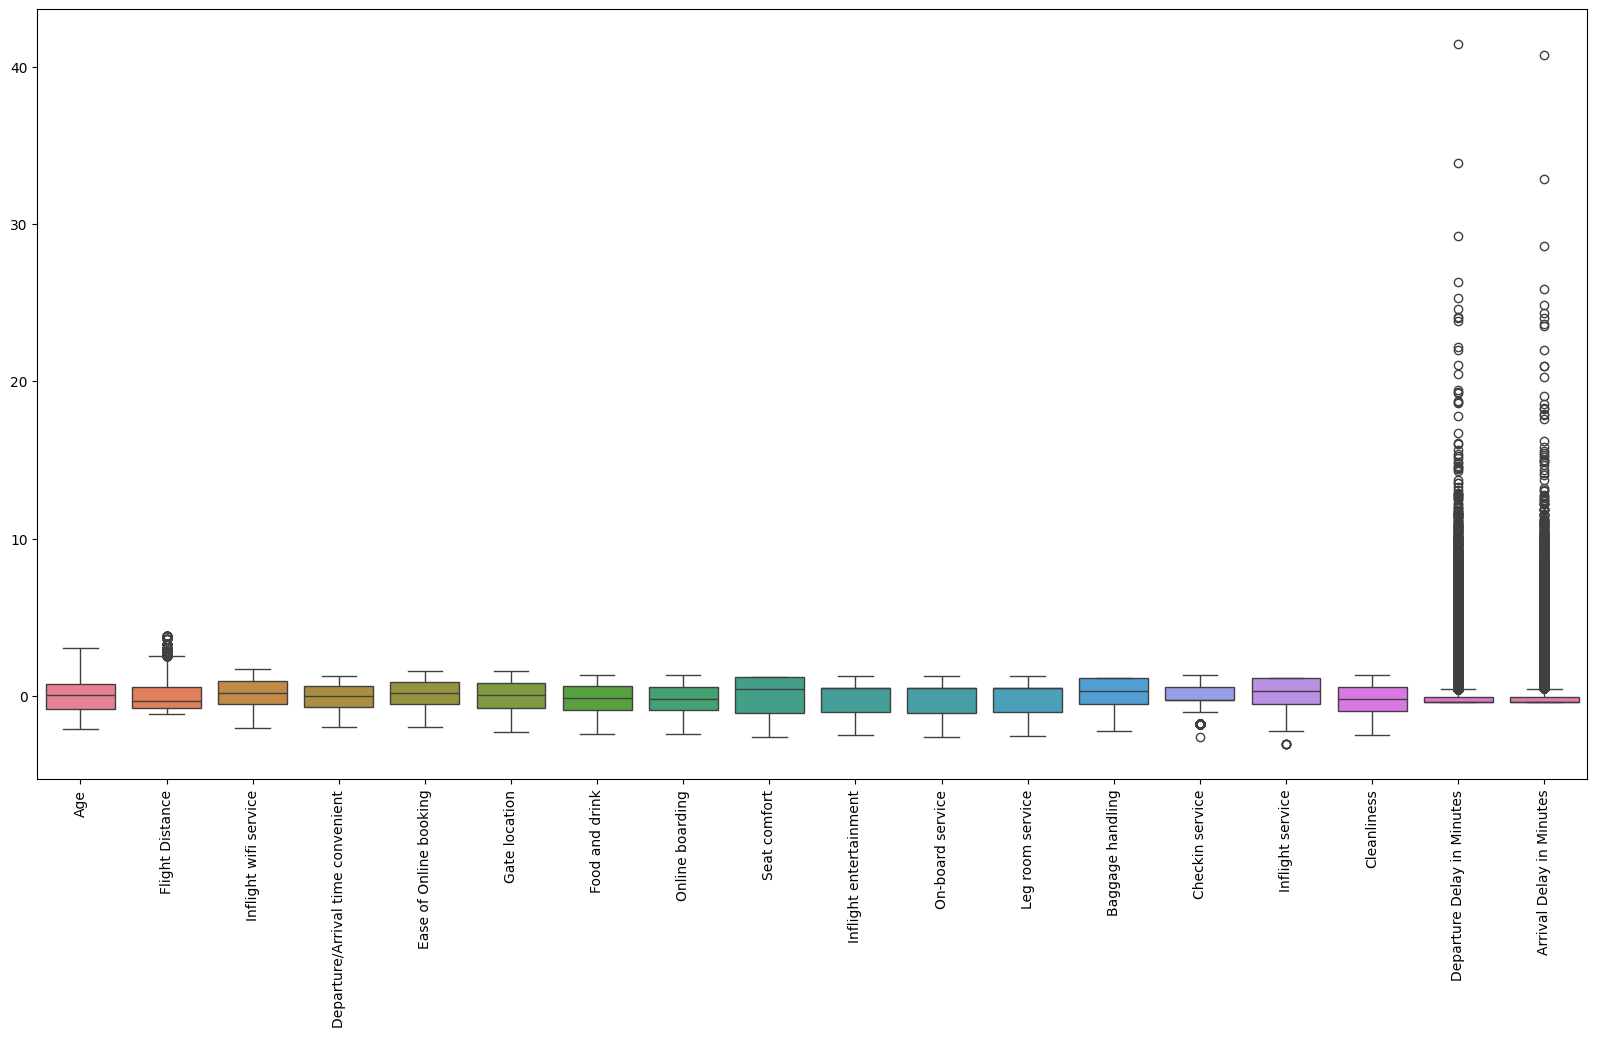

In [15]:
numerical_cols.remove('id')
numerical_cols.remove('Unnamed: 0')
scaled = StandardScaler().fit_transform(df[numerical_cols])
scaled_df = pd.DataFrame(scaled, columns=numerical_cols)

plt.figure(figsize=(20,10))
sb.boxplot(data=scaled_df)
plt.xticks(rotation=90)
plt.show()

Na grafiku vidimo da "Departure delay in minutes", "Arrival delay in minutes" i "Flight distance" imaju "autlajere".

Međutim, kako su ovo real-world podaci, ovi "autlajeri" nisu greške već samo realni podaci (putovanja mogu biti odložena i na par dana, putovanja mogu biti na veće i manje distance... )

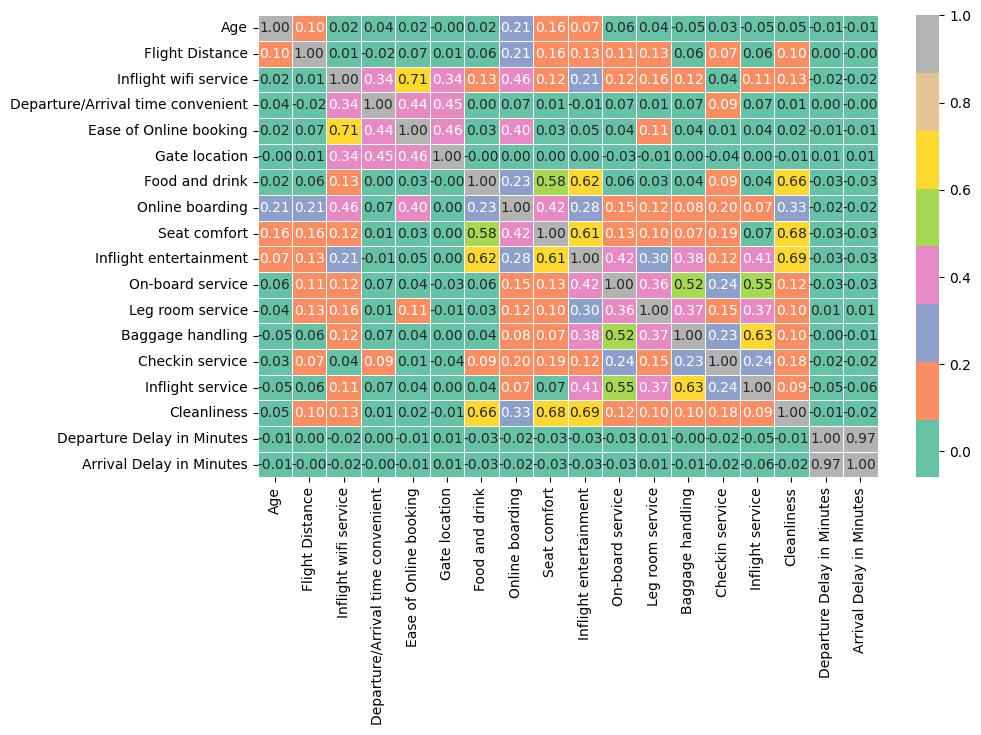

In [16]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 6))
sb.heatmap(
    correlation_matrix,
    annot=True,
    cmap="Set2",   
    fmt=".2f",
    linewidths=.5
)
plt.show()

Primećuje se visoka kolinearnost izmedju departure i arrival delay što ima smisla jer ako avion kasni pri poletanju skoro sigurno kasni i pri dolasku.

Međutim, kako bi izbegli redundantnost i multikolinearnost i poboljšali kasnije predikcije, uklonićemo jednu od kolona.

Takođe, postoji visoka kolinearnost između "Ease of Online Booking" i "Inflight wifi service" (0.71). Ali, kako nisu ista stvar i oba utiču na iskustvo putnika, nećemo ništa više eliminisati.

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Flight Distance'}>,
        <Axes: title={'center': 'Inflight wifi service'}>,
        <Axes: title={'center': 'Departure/Arrival time convenient'}>],
       [<Axes: title={'center': 'Ease of Online booking'}>,
        <Axes: title={'center': 'Gate location'}>,
        <Axes: title={'center': 'Food and drink'}>,
        <Axes: title={'center': 'Online boarding'}>],
       [<Axes: title={'center': 'Seat comfort'}>,
        <Axes: title={'center': 'Inflight entertainment'}>,
        <Axes: title={'center': 'On-board service'}>,
        <Axes: title={'center': 'Leg room service'}>],
       [<Axes: title={'center': 'Baggage handling'}>,
        <Axes: title={'center': 'Checkin service'}>,
        <Axes: title={'center': 'Inflight service'}>,
        <Axes: title={'center': 'Cleanliness'}>],
       [<Axes: title={'center': 'Departure Delay in Minutes'}>,
        <Axes: title={'center': 'Arrival Delay in Minutes'}>, <A

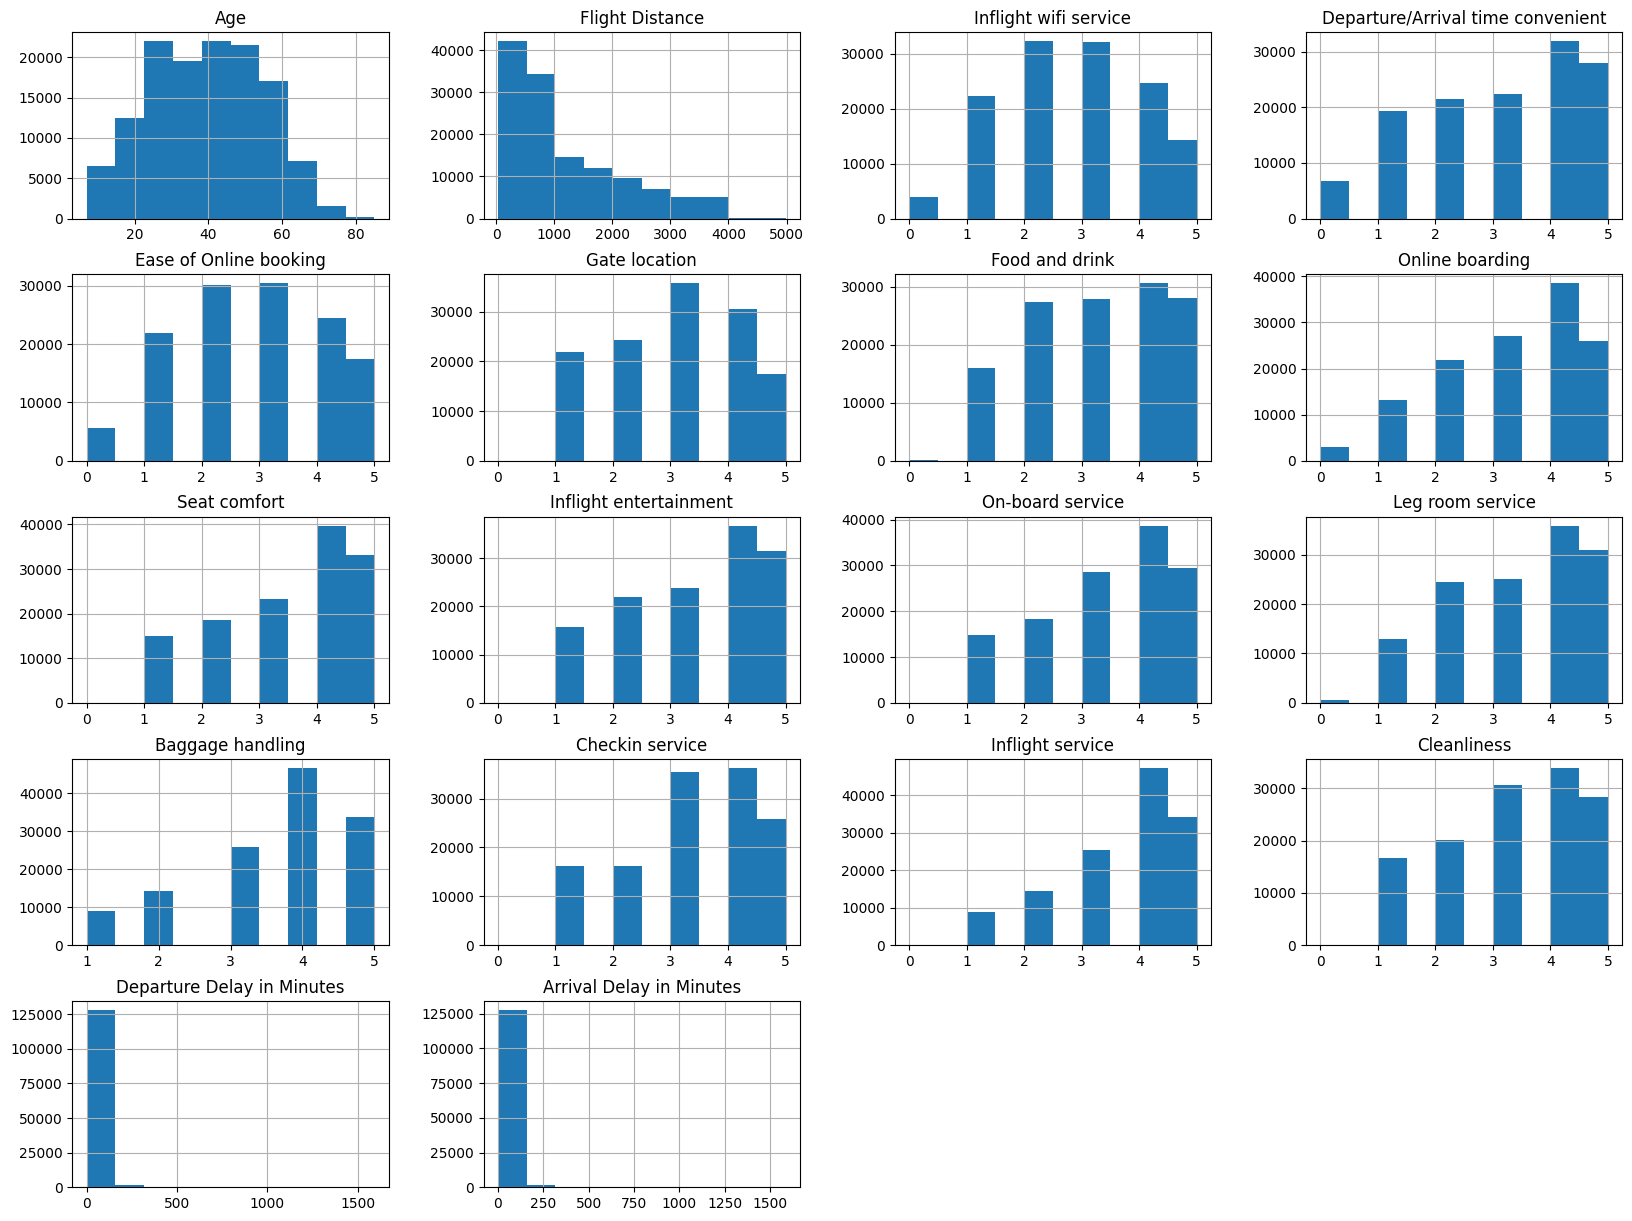

In [19]:
df[numerical_cols].hist(figsize=(20,15))

Za ocene satisfakcije svake usluge su putnici većinski davali dobre ocene (preko 3), jedino za "Inflight wifi service" nadjačava ocena 2 što ukazuje na lošu wifi uslugu u okviru avio kompanija.

# Šta utiče na satisfakciju?

<Axes: xlabel='Flight Distance', ylabel='Count'>

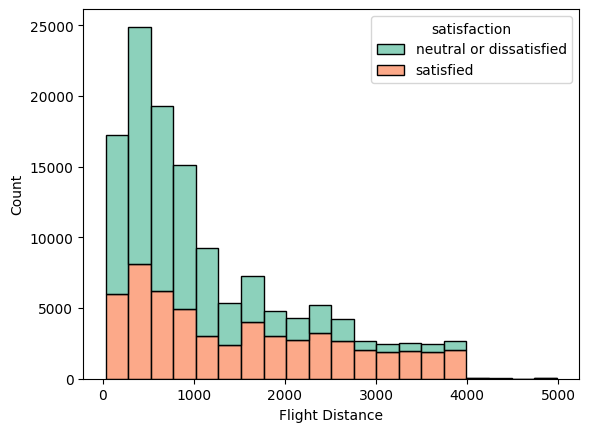

In [29]:
sb.histplot(data=df, x='Flight Distance', hue='satisfaction', multiple='stack', 
                 palette='Set2', bins=20)

<Axes: xlabel='Seat comfort', ylabel='Count'>

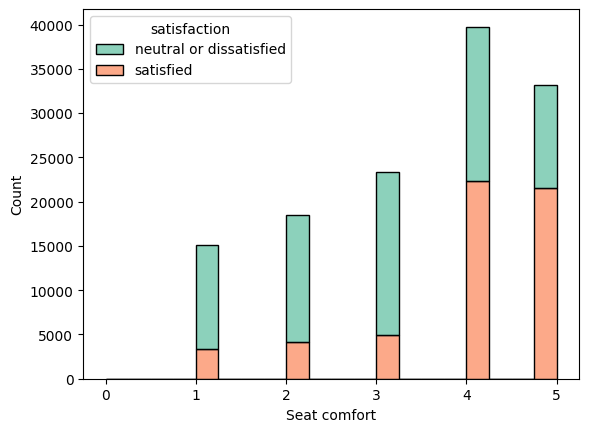

In [30]:
sb.histplot(data=df, x='Seat comfort', hue='satisfaction', multiple='stack', 
                 palette='Set2', bins=20)

<Axes: xlabel='Class', ylabel='Count'>

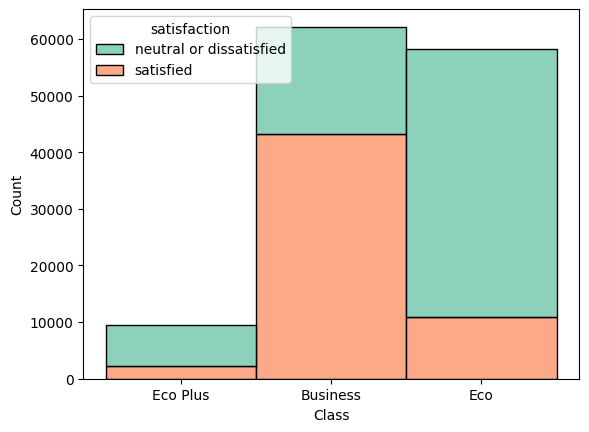

In [35]:
sb.histplot(data=df, x='Class', hue='satisfaction', multiple='stack', 
                 palette='Set2', bins=20)

Rezultati: Klasa putovanja definitivno utiče na zadovoljstvo, kao i udobnost sedišta.

Interesantno, na kraćim distancama je nezadovoljnost veća.